# 01 — EDA: NASA C-MAPSS FD001

This is a "percent" script — open it in VS Code with the Jupyter extension
and it behaves like a notebook (# %% marks cell boundaries), or convert it
with `jupytext` if you prefer a real .ipynb. Either way, run cell by cell.

In [1]:
import sys
from pathlib import Path

sys.path.append(str(Path.cwd().parent))  # so `from src...` imports work

import matplotlib.pyplot as plt
import pandas as pd

from src.config import SENSOR_COLS
from src.data_loader import load_subset
from src.preprocessing import add_rul_to_train, add_rul_to_test, drop_constant_sensors

pd.set_option("display.max_columns", 40)

## Load FD001

In [2]:
train, test, rul_truth = load_subset("FD001")
print("train:", train.shape)
print("test:", test.shape)
print("rul_truth:", rul_truth.shape)
train.head()

train: (20631, 26)
test: (13096, 26)
rul_truth: (100, 2)


,unit_number,time_in_cycles,op_setting_1,op_setting_2,op_setting_3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,sensor_6,sensor_7,sensor_8,sensor_9,sensor_10,sensor_11,sensor_12,sensor_13,sensor_14,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,21.61,554.36,2388.06,9046.19,1.3,47.47,521.66,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,21.61,553.75,2388.04,9044.07,1.3,47.49,522.28,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,21.61,554.26,2388.08,9052.94,1.3,47.27,522.42,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,21.61,554.45,2388.11,9049.48,1.3,47.13,522.86,2388.08,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,21.61,554.00,2388.06,9055.15,1.3,47.28,522.19,2388.04,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044


## Basic shape checks
- How many engines? How many cycles does each run for before failure?

In [3]:
n_engines = train["unit_number"].nunique()
cycles_per_engine = train.groupby("unit_number")["time_in_cycles"].max()
print(f"{n_engines} engines in train")
cycles_per_engine.describe()

100 engines in train


count    100.000000
mean     206.310000
std       46.342749
min      128.000000
25%      177.000000
50%      199.000000
75%      229.250000
max      362.000000
Name: time_in_cycles, dtype: float64

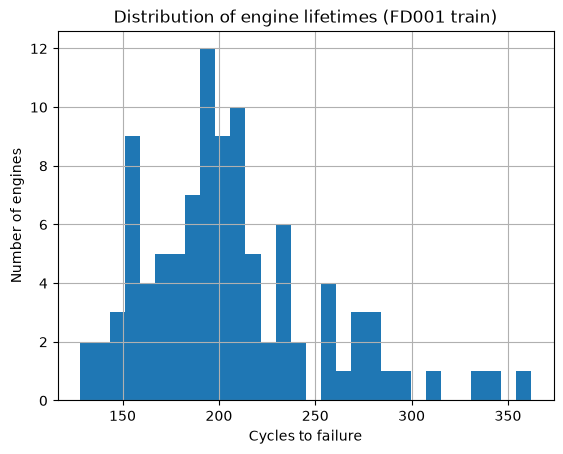

In [4]:
cycles_per_engine.hist(bins=30)
plt.xlabel("Cycles to failure")
plt.ylabel("Number of engines")
plt.title("Distribution of engine lifetimes (FD001 train)")
plt.show()

## Add RUL labels

In [5]:
train = add_rul_to_train(train)
test = add_rul_to_test(test, rul_truth)
train[["unit_number", "time_in_cycles", "RUL"]].head()

,unit_number,time_in_cycles,RUL
0,1,1,125
1,1,2,125
2,1,3,125
3,1,4,125
4,1,5,125


## Which sensors are constant? (candidates to drop)
Don't trust the hardcoded list in config.py blindly — verify per subset.

In [6]:
sensor_std = train[SENSOR_COLS].std().sort_values()
print(sensor_std)

sensor_1     0.000000e+00
sensor_19    0.000000e+00
sensor_18    0.000000e+00
sensor_10    0.000000e+00
sensor_16    3.469531e-18
sensor_5     5.329200e-15
sensor_6     1.388985e-03
sensor_15    3.750504e-02
sensor_8     7.098548e-02
sensor_13    7.191892e-02
sensor_21    1.082509e-01
sensor_20    1.807464e-01
sensor_11    2.670874e-01
sensor_2     5.000533e-01
sensor_12    7.375534e-01
sensor_7     8.850923e-01
sensor_17    1.548763e+00
sensor_3     6.131150e+00
sensor_4     9.000605e+00
sensor_14    1.907618e+01
sensor_9     2.208288e+01
dtype: float64


In [7]:
train["sensor_6"].describe()

count    20631.000000
mean        21.609803
std          0.001389
min         21.600000
25%         21.610000
50%         21.610000
75%         21.610000
max         21.610000
Name: sensor_6, dtype: float64

In [8]:
constant_sensors = ["sensor_1", "sensor_5", "sensor_6", "sensor_10", "sensor_16", "sensor_18", "sensor_19"]

train_reduced = train.drop(columns=constant_sensors)
print("Before:", train.shape)
print("After:", train_reduced.shape)

Before: (20631, 27)
After: (20631, 20)


## Sensor trends vs RUL for a single engine
This is where you build intuition for which sensors actually degrade.

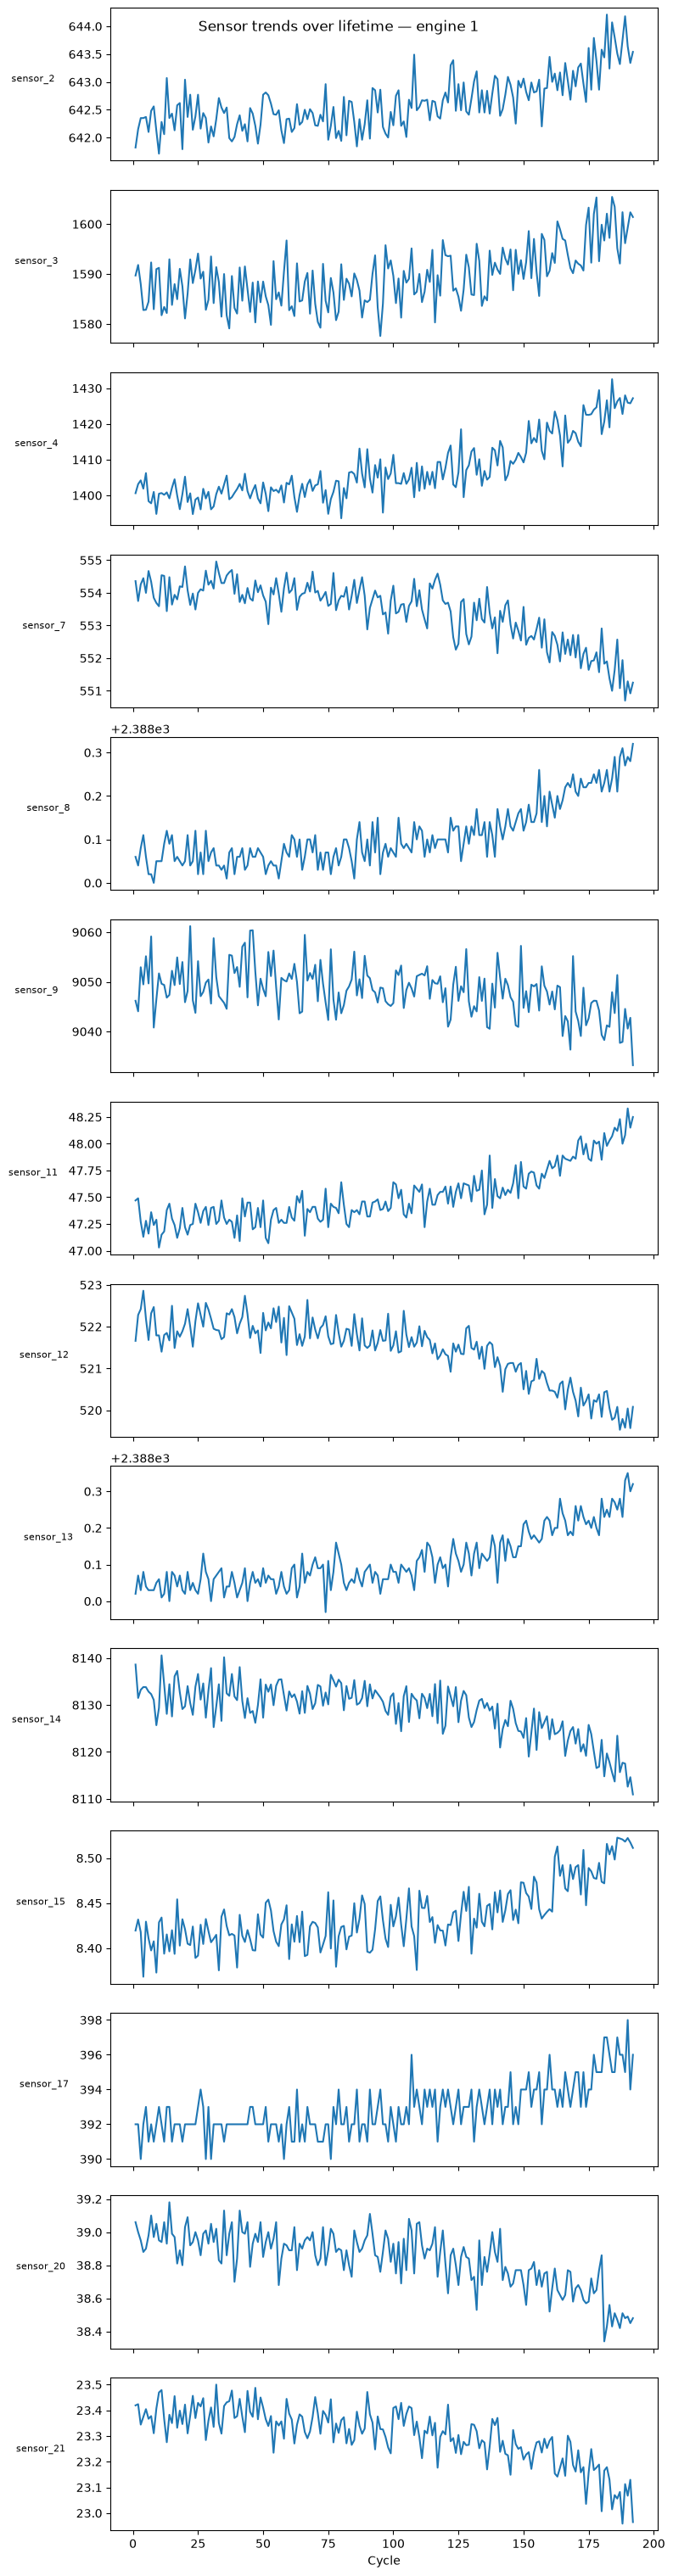

In [12]:
engine_id = 1
engine_data = train[train["unit_number"] == engine_id]

remaining_sensors = [c for c in SENSOR_COLS if c not in constant_sensors]

fig, axes = plt.subplots(len(remaining_sensors), 1, figsize=(8, 2.2 * len(remaining_sensors)), sharex=True)
for ax, sensor in zip(axes, remaining_sensors):
    ax.plot(engine_data["time_in_cycles"], engine_data[sensor])
    ax.set_ylabel(sensor, rotation=0, labelpad=30, fontsize=8)
axes[-1].set_xlabel("Cycle")
fig.suptitle(f"Sensor trends over lifetime — engine {engine_id}")
plt.tight_layout()
plt.show()

## Correlation of each sensor with RUL
Sensors with strong (negative, usually) correlation with RUL are your
strongest degradation indicators — prioritize these in feature engineering.

In [14]:
sensor_cols_remaining = [c for c in train_reduced.columns if c.startswith("sensor_")]

correlations = train_reduced[sensor_cols_remaining + ["RUL"]].corr()["RUL"].drop("RUL")
correlations_sorted = correlations.sort_values()
print(correlations_sorted)

sensor_11   -0.775230
sensor_4    -0.757157
sensor_15   -0.720858
sensor_17   -0.680829
sensor_2    -0.678458
sensor_3    -0.655030
sensor_8    -0.624568
sensor_13   -0.624034
sensor_9    -0.462151
sensor_14   -0.369753
sensor_20    0.704626
sensor_21    0.707334
sensor_7     0.733021
sensor_12    0.748870
Name: RUL, dtype: float64


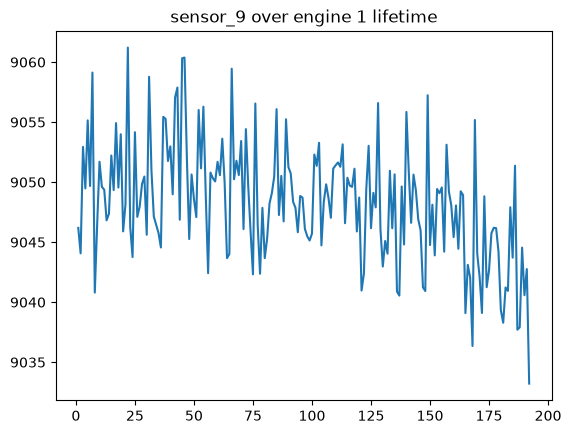

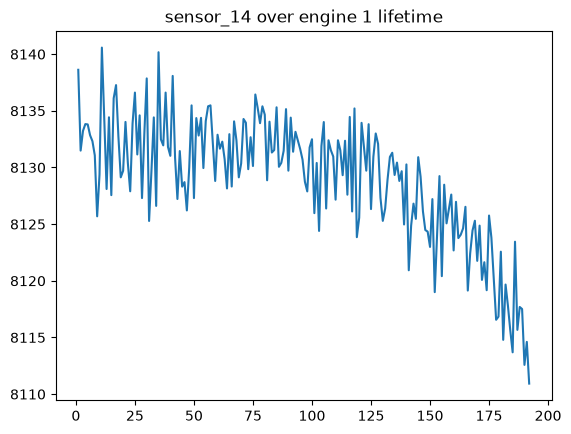

In [15]:
for sensor in ["sensor_9", "sensor_14"]:
    plt.figure()
    plt.plot(engine_data["time_in_cycles"], engine_data[sensor])
    plt.title(f"{sensor} over engine {engine_id} lifetime")
    plt.show()

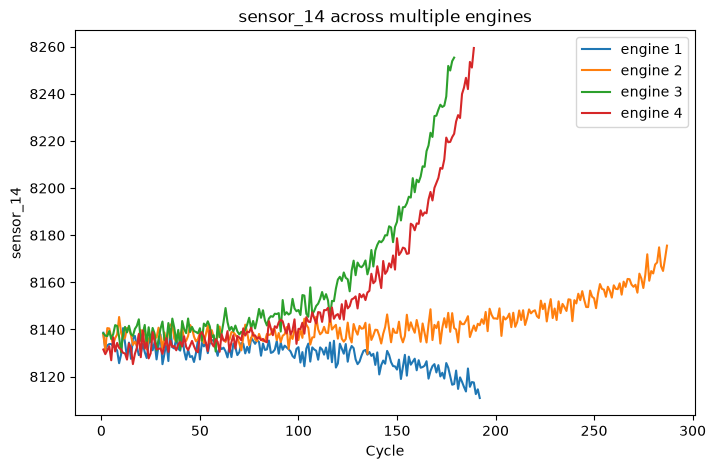

In [16]:
plt.figure(figsize=(8,5))
for eid in [1, 2, 3, 4]:
    e_data = train_reduced[train_reduced["unit_number"] == eid]
    plt.plot(e_data["time_in_cycles"], e_data["sensor_14"], label=f"engine {eid}")
plt.xlabel("Cycle")
plt.ylabel("sensor_14")
plt.legend()
plt.title("sensor_14 across multiple engines")
plt.show()

## Next steps
- Repeat this for FD002/FD003/FD004 — note how sensor behavior differs
  with multiple operating conditions (FD002/FD004).
- Move to `src/features.py` (to be built) for rolling-window feature
  engineering once you've picked your key sensors here.